Algorithm Evaluation: Choosing the best model on basis of different performance metrics.

Importing all the necessary libraries


Read the dataset

In [1]:
# ignore non-harmful warnings
from warnings import filterwarnings
filterwarnings('ignore')

# To read the dataset
import pandas as pd

# To clean the data and preprocess it
# from sklearn.pipeline import make_pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler,OneHotEncoder
# from sklearn.compose import ColumnTransformer
from  data_clean_preprocess1 import clean_process_data


# Divide the data into training and testing
from sklearn.model_selection import train_test_split,cross_val_score

# Model buidling=> Decision Tree, Logistic Regression, Random Forest, Gradient Boost, XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import CategoricalNB



# Evaluation metrics
from sklearn.metrics import f1_score,ConfusionMatrixDisplay,classification_report,accuracy_score

In [2]:
path = r"C:\Users\admin\Downloads\datasets-train.csv"
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [3]:
print(f'Shape of Data:{df.shape}')
print(f'Columns present in dataset: {df.columns}')
print(f'Info of the dataset: {df.info()}')

Shape of Data:(136429, 14)
Columns present in dataset: Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-


Perform basic data quality checks

In [4]:
# Missing values
print(f'Missing Values ')
df.isna().sum()

Missing Values 


id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
## Duplicated rows
print(f'Duplicated rows')
df.duplicated().sum()

Duplicated rows


np.int64(0)

In [6]:
df = df.drop_duplicates()
print('Duplicated rows are dropped')

Duplicated rows are dropped


Separate X and Y features
Y: 'Machine failure'

In [7]:
df.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [8]:
X = df.drop(columns=['id','Machine failure'])
Y = df[['Machine failure']]
print(X.head())
print('-------')
print(Y.head())

  Product ID Type  Air temperature [K]  Process temperature [K]  \
0     L50096    L                300.6                    309.6   
1     M20343    M                302.6                    312.1   
2     L49454    L                299.3                    308.5   
3     L53355    L                301.0                    310.9   
4     M24050    M                298.0                    309.0   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  OSF  \
0                    1596         36.1              140    0    0    0    0   
1                    1759         29.1              200    0    0    0    0   
2                    1805         26.5               25    0    0    0    0   
3                    1524         44.3              197    0    0    0    0   
4                    1641         35.4               34    0    0    0    0   

   RNF  
0    0  
1    0  
2    0  
3    0  
4    0  
-------
   Machine failure
0                0
1                0
2  

Data Preprocessing and Data cleaning

In [9]:
cat = list(X.columns[X.dtypes=='object'])
con = list(X.columns[X.dtypes!='object'])

In [10]:
from data_clean_preprocess1 import clean_process_data

In [ ]:
pre,X_pre = clean_process_data(cat,con,X)
#X_pre.head()

In [ ]:
pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=21)
print(f'xtrain.shape: {xtrain.shape}')
print(f'xtest.shape: {xtest.shape}')
print(f'ytrain.shape: {ytrain.shape}')
print(f'ytest.shape: {ytest.shape}')

xtrain.shape: (102321, 9989)
xtest.shape: (34108, 9989)
ytrain.shape: (102321, 1)
ytest.shape: (34108, 1)


In [ ]:
df['Machine failure'].value_counts()

Machine failure
0    134281
1      2148
Name: count, dtype: int64

balance the data using class_weight

Algorithm Evaluation

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

In [ ]:
models =[
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    XGBClassifier(),
    BernoulliNB()
]

In [ ]:

models[1]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(k_neighbors = 3)
x_sampl,y_sampl = smote.fit_resample(xtrain,ytrain)


MemoryError: Unable to allocate 7.38 GiB for an array with shape (99105, 9989) and data type float64

In [ ]:
def evaluate_model_performance(model,x_sampl,y_sampl,xtest,ytest):
    # Fit the model
    
    model.fit(x_sampl,y_sampl)

    # Predict the outputs-Machine Failiure
    ypred_train = model.predict(x_sampl)
    ypred_test = model.predict(xtest)

    # Evaluation on basis of metrics: f1-score
    f1_train = f1_score(x_sampl,ypred_train)
    f1_test = f1_score(ytest,ypred_test)

    # Evaluate through cross validation also
    scores = cross_val_score(model,x_sampl,y_sampl,cv=4,scoring='f1_macro')
    f1_cv = scores.mean()
   
    # Accuray Score on train dataset
    accuracy_train = accuracy_score(y_sampl,ypred_train)
    print('accuracy_score on train dataset : ', accuracy_train)

    # Accuracy Score on test dataset
    accuracy_test = accuracy_score(ytest,ypred_test )
    print('accuracy_score on test dataset : ',accuracy_test)


    # Returns all the above results for the model
    results = {
        'Name':type(model).__name__,
        'f1-score:training':f1_train,
        'f1-score:testing':f1_test,
        'f1-cv':f1_cv,
        'accuracy_score :training': accuracy_train,
        'accuracy_score :training':accuracy_test 

    }
    return results

In [ ]:

models

[LogisticRegression(class_weight='balanced'),
 DecisionTreeClassifier(class_weight='balanced'),
 RandomForestClassifier(class_weight='balanced'),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               class_weight='balanced', colsample_bylevel=None,
               colsample_bynode=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None, ...),
 BernoulliNB()]

In [ ]:
def evaluate_model(models,x_sampl,y_sampl,xtest,ytest):
    res = []
    for m in models:
        r = evaluate_model_performance(m,x_sampl,y_sampl,xtest,ytest)

        # combine all the results of each model provided as input to above method into a res list
        res.append(r)
    # Convert these results into a dataframe and display
    results_df = pd.DataFrame(res)
    return results_df

In [ ]:
score_results_df = evaluate_model(models,x_sampl,y_sampl,xtest,ytest)

NameError: name 'predict_train' is not defined

In [ ]:

score_results_df

,Name,f1-score:training,f1-score:testing,f1-cv
0,LogisticRegression,0.631869,0.640739,0.789652
1,DecisionTreeClassifier,1.000000,0.693953,0.823947
2,RandomForestClassifier,1.000000,0.802469,0.888427
3,GradientBoostingClassifier,0.808484,0.802982,0.886305
4,XGBClassifier,0.870495,0.810980,0.891150


In [ ]:

score_results_df.sort_values(by='f1-cv',ascending=False)

,Name,f1-score:training,f1-score:testing,f1-cv
4,XGBClassifier,0.870495,0.810980,0.891150
2,RandomForestClassifier,1.000000,0.802469,0.888427
3,GradientBoostingClassifier,0.808484,0.802982,0.886305
1,DecisionTreeClassifier,1.000000,0.693953,0.823947
0,LogisticRegression,0.631869,0.640739,0.789652


Finalising XGBClassifier on basis of highest f1-cv scores

In [ ]:
final_model = XGBClassifier()
final_model.fit(x_sampl,y_sampl)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
final_model.score(x_sampl,y_sampl)

0.9664188436441352

In [ ]:
final_model.score(xtest,ytest)

0.9506888555449461

Model Evaluation using confusion matrix, classification report, ROC-AUC curve

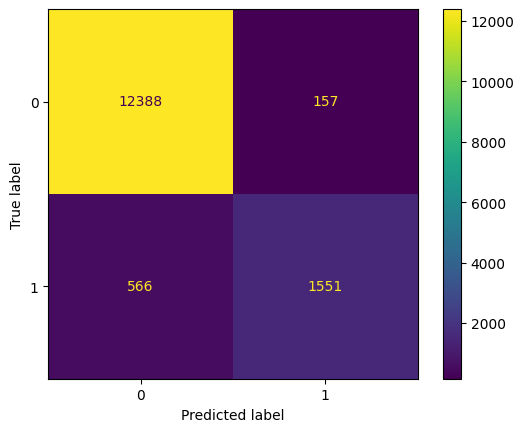

In [ ]:
ConfusionMatrixDisplay.from_estimator(final_model,xtest,ytest)

In [ ]:

print(classification_report(ytest,final_model.predict(xtest)))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     12545
           1       0.91      0.73      0.81      2117

    accuracy                           0.95     14662
   macro avg       0.93      0.86      0.89     14662
weighted avg       0.95      0.95      0.95     14662




Using this model for final predictions

In [ ]:
import pandas as pd
path2 = r'C:\Users\admin\Downloads\datasets-test.csv'
xnew = pd.read_csv(path2)
xnew.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:

xnew_pre = pre.transform(xnew)

In [ ]:

xnew_pre.head()

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,-0.754307,0.130602,-0.429576,2.836651,1.674687,2.189555,-0.946489
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,-0.257055,0.842425,0.328047,0.140632,0.659750,-0.646056,-0.450108
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,-0.257055,-0.897587,0.075506,-0.937775,2.145908,-0.318870,-0.946489
3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.903198,-0.370311,-0.177035,-0.398572,-0.585854,-0.209808,0.294464
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.257055,1.000608,0.833130,1.039305,1.859221,-0.100746,-0.450108


In [ ]:
Machine_Failiure_predicted = final_model.predict(xnew_pre)
Machine_Failiure_predicted[:5]

array([1, 0, 1, 0, 0])

In [ ]:
xnew['Machine failiure Predicted'] = Machine_Failiure_predicted
xnew.to_csv('Machine Failiure Results.csv',index=False)